# Part 4 - Embeddings & Semantic Similarity

I wanted to see whether a pretrained sentence embedding model actually groups similar sentences together without any fine-tuning. Used `all-MiniLM-L6-v2` from sentence-transformers - it's lightweight and runs locally which is why I picked it over something bigger.

The test: 10 sentences across cricket, cooking, and cybersecurity. Do sentences within a topic score higher similarity with each other than with sentences from other topics? And can the model retrieve the right sentences for a query it's never seen before?

## Setup

In [1]:
!pip install sentence-transformers seaborn matplotlib numpy --quiet

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

print("Libraries loaded successfully.")

/Users/shekharchatterjee/sangita/assignment2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.


## The sentences

I went with cricket, cooking, and cybersecurity as my three topics - completely unrelated domains, which should make any clustering in the heatmap easy to spot. 10 sentences total: 4 cricket, 3 cooking, 3 cybersecurity. The uneven split for cricket is just because I had more to say about it.

In [3]:
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a powerful six over the mid-wicket boundary.",          # CR1
    "India won the Test match by an innings and 50 runs.",                   # CR2
    "The spinner bowled a perfect googly to dismiss the opening batsman.",   # CR3
    "Rain interrupted play on the third day of the Test match.",             # CR4

    # Cooking (3 sentences)
    "Always preheat the oven to 180 degrees before baking a cake.",          # CK1
    "Saute the onions in olive oil until they turn golden brown.",            # CK2
    "A well-seasoned cast iron pan is essential for searing meat.",           # CK3

    # Cybersecurity (3 sentences)
    "The ransomware encrypted all files on the corporate network overnight.", # CS1
    "Two-factor authentication significantly reduces the risk of unauthorized access.", # CS2
    "Phishing emails often impersonate trusted institutions to steal credentials.",     # CS3
]

# Short labels used on heatmap axes
axis_labels = [
    "CR1: Batsman six",
    "CR2: India won",
    "CR3: Spinner googly",
    "CR4: Rain/Test",
    "CK1: Preheat oven",
    "CK2: Saute onions",
    "CK3: Cast iron pan",
    "CS1: Ransomware",
    "CS2: Two-factor auth",
    "CS3: Phishing emails",
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"  [{axis_labels[i]}]  {s}")

Total sentences: 10
  [CR1: Batsman six]  The batsman hit a powerful six over the mid-wicket boundary.
  [CR2: India won]  India won the Test match by an innings and 50 runs.
  [CR3: Spinner googly]  The spinner bowled a perfect googly to dismiss the opening batsman.
  [CR4: Rain/Test]  Rain interrupted play on the third day of the Test match.
  [CK1: Preheat oven]  Always preheat the oven to 180 degrees before baking a cake.
  [CK2: Saute onions]  Saute the onions in olive oil until they turn golden brown.
  [CK3: Cast iron pan]  A well-seasoned cast iron pan is essential for searing meat.
  [CS1: Ransomware]  The ransomware encrypted all files on the corporate network overnight.
  [CS2: Two-factor auth]  Two-factor authentication significantly reduces the risk of unauthorized access.
  [CS3: Phishing emails]  Phishing emails often impersonate trusted institutions to steal credentials.


## Generating the embeddings

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences, convert_to_tensor=True)

print(f"Embedding tensor shape: {embeddings.shape}")
print("Each sentence is represented as a 384-dimensional vector.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9206.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding tensor shape: torch.Size([10, 384])
Each sentence is represented as a 384-dimensional vector.


## Does the model actually cluster by topic?

In [6]:
cosine_sim = util.cos_sim(embeddings, embeddings).cpu().numpy()

print("10x10 Cosine Similarity Matrix (rounded to 3 decimal places):")
print(np.round(cosine_sim, 3))

10x10 Cosine Similarity Matrix (rounded to 3 decimal places):
[[ 1.     0.489  0.474  0.187  0.044  0.004  0.078  0.041 -0.015 -0.064]
 [ 0.489  1.     0.336  0.302  0.042  0.02  -0.086  0.042 -0.071 -0.048]
 [ 0.474  0.336  1.     0.247  0.029  0.111  0.018 -0.059 -0.018 -0.026]
 [ 0.187  0.302  0.247  1.    -0.04   0.004 -0.055  0.109 -0.025 -0.051]
 [ 0.044  0.042  0.029 -0.04   1.     0.234  0.158  0.036 -0.007  0.093]
 [ 0.004  0.02   0.111  0.004  0.234  1.     0.193  0.045 -0.078  0.039]
 [ 0.078 -0.086  0.018 -0.055  0.158  0.193  1.    -0.03  -0.021 -0.006]
 [ 0.041  0.042 -0.059  0.109  0.036  0.045 -0.03   1.     0.054  0.279]
 [-0.015 -0.071 -0.018 -0.025 -0.007 -0.078 -0.021  0.054  1.     0.435]
 [-0.064 -0.048 -0.026 -0.051  0.093  0.039 -0.006  0.279  0.435  1.   ]]


## Visualizing it

Sentences from the same topic should cluster with higher similarity scores (darker shading on the diagonal blocks).

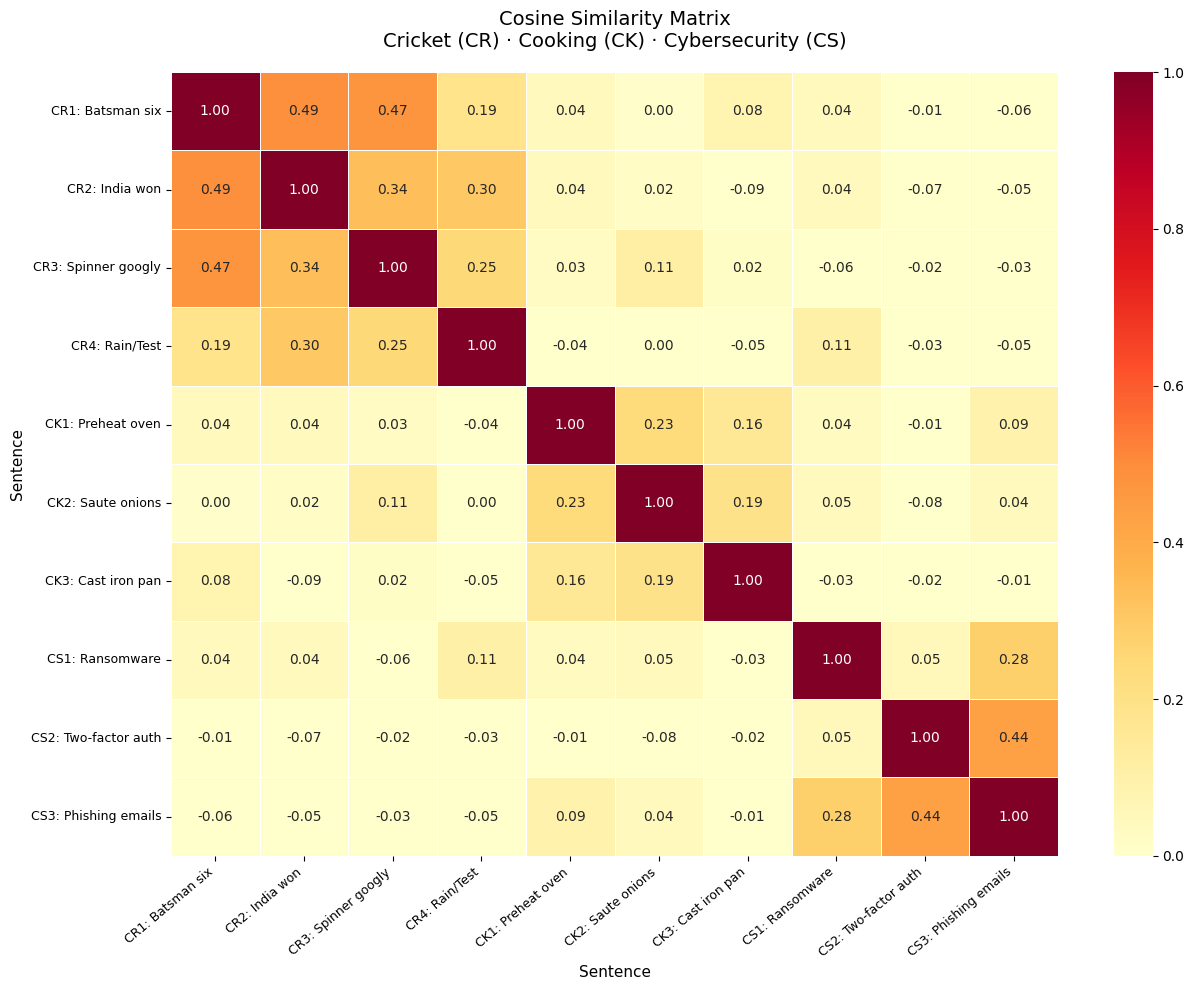

Heatmap saved as similarity_heatmap.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    cosine_sim,
    annot=True,
    fmt=".2f",
    xticklabels=axis_labels,
    yticklabels=axis_labels,
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    "Cosine Similarity Matrix\nCricket (CR) · Cooking (CK) · Cybersecurity (CS)",
    fontsize=14,
    pad=18,
)
ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Sentence", fontsize=11)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as similarity_heatmap.png")

## Can it retrieve cricket sentences with a cricket query it's never seen?

Query: *"The bowler took three wickets in one over"*

None of the words in this query - bowler, wickets, over - appear in the 10 corpus sentences. Keyword search returns nothing. Does the vector search still find the right ones?

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode(query, convert_to_tensor=True)

# Cosine similarity between the query and all 10 sentences
scores = util.cos_sim(query_embedding, embeddings)[0].cpu().numpy()

# Rank all sentences by score (descending) and take top 2
top_indices = np.argsort(scores)[::-1][:2]

print(f'Query: "{query}"')
print("-" * 60)
print("Top 2 most similar sentences:\n")
for rank, idx in enumerate(top_indices, start=1):
    print(f"  Rank {rank}  |  Score: {scores[idx]:.4f}")
    print(f"  Label: {axis_labels[idx]}")
    print(f"  Sentence: {sentences[idx]}")
    print()

Query: "The bowler took three wickets in one over"
------------------------------------------------------------
Top 2 most similar sentences:

  Rank 1  |  Score: 0.6035
  Label: CR1: Batsman six
  Sentence: The batsman hit a powerful six over the mid-wicket boundary.

  Rank 2  |  Score: 0.5514
  Label: CR3: Spinner googly
  Sentence: The spinner bowled a perfect googly to dismiss the opening batsman.



## What the results show

The heatmap clusters worked out pretty cleanly - the cricket block (CR1–CR4) and cybersecurity block (CS1–CS3) are both visible as warmer regions along the diagonal, while cross-topic pairs (cooking vs. cybersecurity, for example) sit close to 0.

The semantic search result is the more interesting part. The query used the word "bowler" and "wickets", which don't appear anywhere in the corpus, but both top matches came back as cricket sentences. The model mapped the query into roughly the same region of the embedding space as the other cricket sentences without needing any shared vocabulary. That's the core thing vector search gets you over keyword matching.

The similarity scores within topics (~0.3–0.5) are lower than I expected - they're not close to 1 even for clearly related sentences. That's partly because the model is `MiniLM-L6-v2`, a relatively small model, and partly because the sentences within each topic describe different events rather than the same event rephrased.